# ISyE 6740 Project

In [1]:
import time
import random
import h5py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # the tidy way

In [2]:
from platform import python_version
print(python_version())

3.11.4


## 1. Read PCam data

In [3]:
os.getcwd()
# os.chdir('..')

'C:\\Users\\a_lar\\OneDrive\\00.GTech\\10.ISYE6740_comp_an\\2.Project\\histo\\pcam'

read from h5 files

In [4]:
PATH = './db/'
data = dict()
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    file = 'camelyonpatch_level_2_split_' + s + '.h5'
    data[s] = h5py.File(PATH + file + '/' +  file, "r")

In [5]:
for s in ['train_x', 'train_y', 'test_x', 'test_y']:
    for k in data[s].keys():
        print(s, k)
        dset = data[s][k]
        display(dset.shape)

train_x x


(262144, 96, 96, 3)

train_y y


(262144, 1, 1, 1)

test_x x


(32768, 96, 96, 3)

test_y y


(32768, 1, 1, 1)

In [6]:
# img_arr = X_train[0]
# r,c,l = img_arr.shape
# print("Shape of the 3D matrix obtained from image: ", r, c, l)
# pixels = img_arr.ravel().reshape(img_arr.shape[0]*img_arr.shape[1], 3)
# print("Shape of the 2D matrix obtained by flattening the previous image (ie the 'pixels' matrix): ", pixels.shape)
# print("\n        Original Image:")
# plt.imshow(img_arr)

## 4. Create downsamples and convert images to grayscale

Create downsamples and convert images to grayscale

In [7]:
len(data['train_x']['x'])

262144

In [8]:
ntrain = 1000
ntest =  500
train_idx = np.sort(np.random.choice(len(data['train_x']['x']), size=ntrain,replace=False))
test_idx = np.sort(np.random.choice(len(data['test_x']['x']), size=ntest,replace=False))
X_train_0 = data['train_x']['x'][train_idx]
X_test_0  = data['test_x']['x'][test_idx]
y_train = np.array(data['train_y']['y'][train_idx]).ravel()
y_test  = np.array(data['test_y']['y'][test_idx]).ravel()
X_train_0.shape, y_train.shape, X_test_0.shape, y_test.shape

((1000, 96, 96, 3), (1000,), (500, 96, 96, 3), (500,))

train images to grayscale

In [9]:
X_train_g = np.ones([ntrain, 96, 96]) * np.inf
X_test_g  = np.ones([ntest,  96, 96]) * np.inf
X_train_g.shape, X_test_g.shape, X_train_g[10,:2,:2]

((1000, 96, 96),
 (500, 96, 96),
 array([[inf, inf],
        [inf, inf]]))

In [10]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntrain):
    for i in range(96):
        for j in range(96):
            X_train_g[n][i,j] = wt @ X_train_0[n][i,j] / 255
X_train_g.shape

(1000, 96, 96)

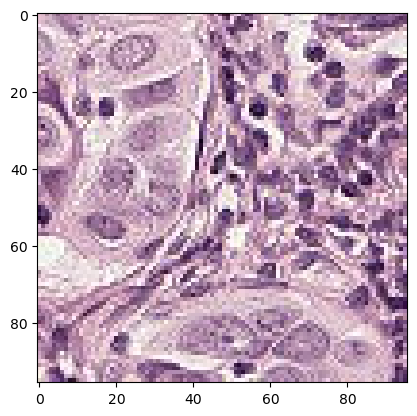

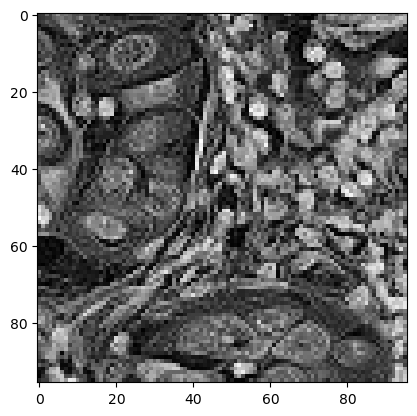

((96, 96, 3),
 (96, 96),
 array([[[230, 189, 205],
         [222, 185, 202]],
 
        [[231, 192, 210],
         [227, 190, 207]]], dtype=uint8),
 array([[0.79631373, 0.77638745],
        [0.80662706, 0.79599333]]))

In [11]:
plt.imshow(X_train_0[10]); plt.show()
plt.imshow(X_train_g[10], cmap=plt.get_cmap('binary')); plt.show()
X_train_0[10].shape, X_train_g[10].shape, X_train_0[10][:2,:2], X_train_g[10][:2,:2]

In [12]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntest):
    for i in range(96):
        for j in range(96):
            X_test_g[n][i,j] = wt @ X_test_0[n][i,j] / 255
X_test_g.shape

(500, 96, 96)

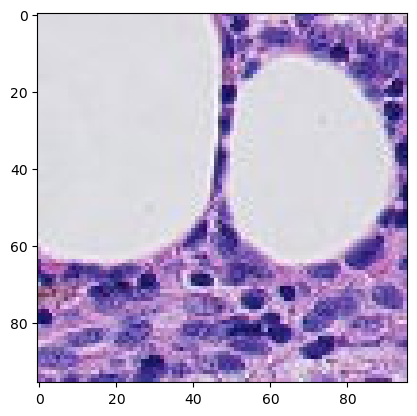

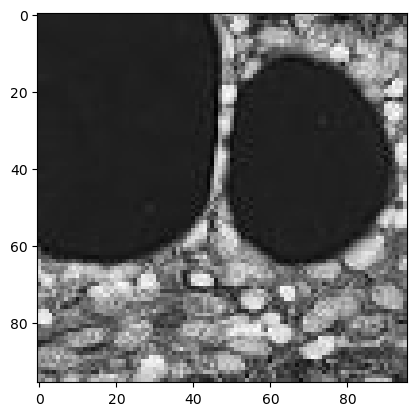

((96, 96, 3),
 (96, 96),
 array([[[219, 218, 224],
         [219, 218, 224]],
 
        [[219, 218, 224],
         [219, 218, 224]]], dtype=uint8),
 array([[0.85867098, 0.85867098],
        [0.85867098, 0.85867098]]))

In [13]:
plt.imshow(X_test_0[10]); plt.show()
plt.imshow(X_test_g[10], cmap=plt.get_cmap('binary')); plt.show()
X_test_0[10].shape, X_test_g[10].shape, X_test_0[10][:2,:2], X_test_g[10][:2,:2]

Extract 32 x 32 center

In [14]:
X_train = np.ones([ntrain, 32*32]) * np.inf
X_test  = np.ones([ntest,  32*32]) * np.inf
X_train.shape, X_test.shape

((1000, 1024), (500, 1024))

In [15]:
for i in range(ntrain):
    X_train[i] = X_train_g[i][32:(32*2),32:(32*2)].ravel()
for j in range(ntest):
    X_test[j] = X_test_g[j][32:(32*2),32:(32*2)].ravel()

In [16]:
print('X_train: ', type(X_train), X_train.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test: ', type(X_test), X_test.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train:  <class 'numpy.ndarray'> (1000, 1024)
y_train:  <class 'numpy.ndarray'> (1000,) [1 0 0 0 1]
X_test:  <class 'numpy.ndarray'> (500, 1024)
y_test:  <class 'numpy.ndarray'> (500,) [0 0 1 0 1]


In [17]:
np.sum(np.isinf(X_train)), np.sum(np.isinf(X_test))

(0, 0)

Display a few images

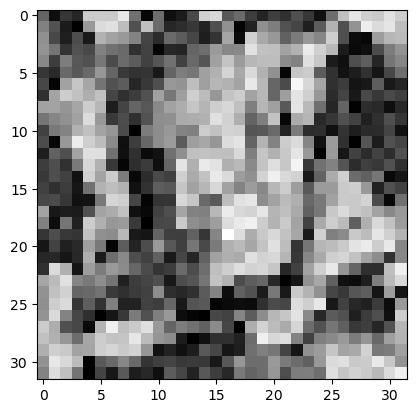

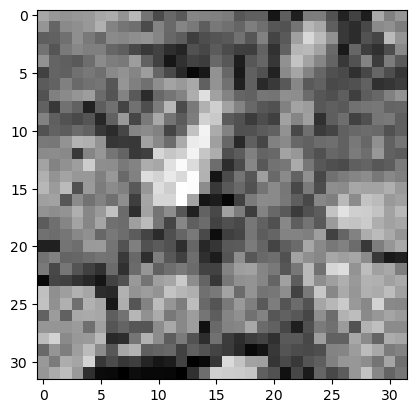

In [18]:
for i in np.random.choice(ntrain, 2, replace = False):
    plt.imshow(X_train[i].reshape([32,32]), cmap=plt.get_cmap('binary'))
    plt.show()

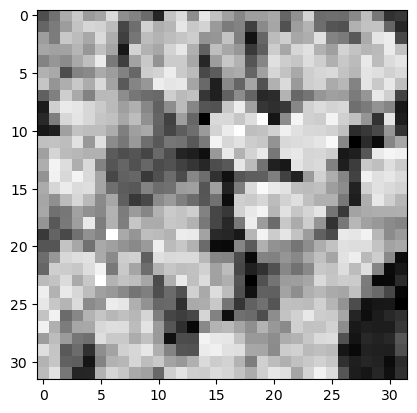

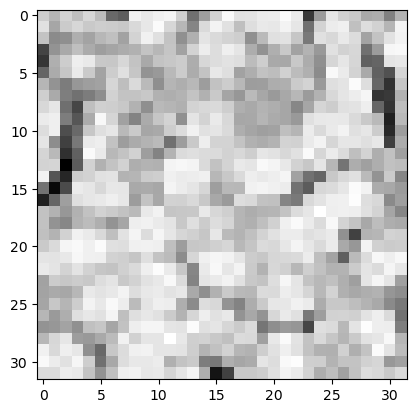

In [19]:
for i in np.random.choice(ntest, 2, replace = False):
    plt.imshow(X_test[i].reshape([32,32]), cmap=plt.get_cmap('binary'))
    plt.show()

Te reshape aftwerwards: 

In [20]:
# X_train[0].reshape(96,96,3)

In [21]:
# plt.imshow(X_train[0].reshape(96,96,3)); plt.show()
# plt.imshow(X_test[0].reshape(96,96,3)); plt.show()

## 5. Fit classifiers on 32x32 images

In [22]:
import warnings

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.svm import NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import AdaBoostClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support

Define a function to get classification performance metrics:

In [23]:
def get_metrics(predicted_y, test_y):
    d = {}
    acc, bal_acc = accuracy_score(test_y,predicted_y), balanced_accuracy_score(test_y,predicted_y)
    precision, recall, F1_score, support = precision_recall_fscore_support(test_y, predicted_y, average=None)
    d['confusion'] = confusion_matrix(test_y, predicted_y)
    d['accuracy'] = acc
    d['balanced_accuracy'] = bal_acc
    d['precision'] = precision
    d['recall'] = recall
    d['F1_score'] = F1_score
    d['support'] = support
    return d

Define classification parameters for KNN and Neural Net and regularization parameter for SVM:

In [24]:
k = 5   # KNN
C, gamma = 5, 0.5   # SVM regularization parameter
n_learners = 100
random_state = 301

Define lists with different classifiers:

In [26]:
keys = ['KNN', 'LogReg','KSVM','Net','Ada']
pretty_keys = ['KNN', 'Logistic Regression', 'Kernel SVM', 'Neural Net', 'AdaBoost']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        LogisticRegression(solver = 'liblinear', multi_class='auto', random_state = random_state), 
        svm.SVC(kernel='rbf',
                gamma='scale', 
                C=C, 
                random_state = random_state),
        MLPClassifier(hidden_layer_sizes=(100,),
                      max_iter = 10,
                      alpha=1e-4,
                      solver='sgd',
                      verbose=10,
                      random_state=random_state, 
                      learning_rate='adaptive',
                      learning_rate_init=.01),
       AdaBoostClassifier(
            DecisionTreeClassifier(max_depth=10), 
            n_estimators=n_learners)]

Fit classifiers to training data within a loop:

In [27]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs, keys):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
    
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.002001 seconds 


 LogReg finished in 0.244181 seconds 


 KSVM finished in 0.130592 seconds 

Iteration 1, loss = 0.80928583
Iteration 2, loss = 0.69631062
Iteration 3, loss = 0.69461489
Iteration 4, loss = 0.68428903
Iteration 5, loss = 0.68098018
Iteration 6, loss = 0.67513853
Iteration 7, loss = 0.67485265
Iteration 8, loss = 0.66892182
Iteration 9, loss = 0.66956090
Iteration 10, loss = 0.66280380

 Net finished in 0.208958 seconds 



C:\Users\a_lar\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(



 Ada finished in 155.750979 seconds 

Total elapsed time: 2.606762 minutes 



Report Confusion Marices:

In [28]:
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 KNN :


,0,1
0,83,165
1,17,235



 Logistic Regression :


,0,1
0,141,107
1,106,146



 Kernel SVM :


,0,1
0,166,82
1,68,184



 Neural Net :


,0,1
0,197,51
1,174,78



 AdaBoost :


,0,1
0,133,115
1,70,182


Report performance metrics:

In [29]:
for metric in ['accuracy','balanced_accuracy']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.Series(mts).round(2))

for metric in ['precision','recall','F1_score']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.DataFrame(mts).round(2))


accuracy


KNN       0.64
LogReg    0.57
KSVM      0.70
Net       0.55
Ada       0.63
dtype: float64


balanced_accuracy


KNN       0.63
LogReg    0.57
KSVM      0.70
Net       0.55
Ada       0.63
dtype: float64


precision


,KNN,LogReg,KSVM,Net,Ada
0,0.83,0.57,0.71,0.53,0.66
1,0.59,0.58,0.69,0.60,0.61



recall


,KNN,LogReg,KSVM,Net,Ada
0,0.33,0.57,0.67,0.79,0.54
1,0.93,0.58,0.73,0.31,0.72



F1_score


,KNN,LogReg,KSVM,Net,Ada
0,0.48,0.57,0.69,0.64,0.59
1,0.72,0.58,0.71,0.41,0.66


## 6. Fine tune KNN and KSVM with SearchCV

In [30]:
from time import time

import numpy as np
import scipy.stats as stats

from sklearn.datasets import load_digits
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [31]:
# Utility function to report best scores
def report(results, n_top=3):
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results["rank_test_score"] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print(
                "Mean validation score: {0:.3f} (std: {1:.3f})".format(
                    results["mean_test_score"][candidate],
                    results["std_test_score"][candidate],
                )
            )
            print("Parameters: {0}".format(results["params"][candidate]))
            print("")

#### KNN

In [32]:
# build a classifier & specify parameters and distributions to sample from
clf = KNeighborsClassifier()
param_dist = {"n_neighbors": stats.randint(3, 50)}

# run randomized search
n_iter_search = 10
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time() - start), n_iter_search))

report(random_search.cv_results_)

# use a full grid over all parameters
param_grid = {"n_neighbors": [3,5,10,15,20,25,30]}

# run grid search
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time()
grid_search.fit(X_train, y_train)

print("GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time() - start, len(grid_search.cv_results_["params"])))

report(grid_search.cv_results_)

RandomizedSearchCV took 1.62 seconds for 10 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.631 (std: 0.037)
Parameters: {'n_neighbors': 4}

Model with rank: 2
Mean validation score: 0.627 (std: 0.039)
Parameters: {'n_neighbors': 5}

Model with rank: 3
Mean validation score: 0.626 (std: 0.039)
Parameters: {'n_neighbors': 9}

Model with rank: 3
Mean validation score: 0.626 (std: 0.042)
Parameters: {'n_neighbors': 14}

Model with rank: 3
Mean validation score: 0.626 (std: 0.042)
Parameters: {'n_neighbors': 14}

GridSearchCV took 1.11 seconds for 7 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.627 (std: 0.039)
Parameters: {'n_neighbors': 5}

Model with rank: 1
Mean validation score: 0.627 (std: 0.037)
Parameters: {'n_neighbors': 10}

Model with rank: 3
Mean validation score: 0.623 (std: 0.034)
Parameters: {'n_neighbors': 15}

Model with rank: 3
Mean validation score: 0.623 (std: 0.039)
Parameters: {'n_neighbors': 25}



#### KSVM

In [33]:
# build a classifier & specify parameters and distributions to sample from
clf = svm.SVC(kernel='rbf',random_state = random_state)
param_dist = {"gamma": stats.uniform(0,3),
              "C":stats.randint(1,20) }

# run randomized search
n_iter_search = 10
random_search = RandomizedSearchCV(clf, param_distributions=param_dist, n_iter=n_iter_search)

start = time()
random_search.fit(X_train, y_train)
print("RandomizedSearchCV took %.2f seconds for %d candidates parameter settings."
    % ((time() - start), n_iter_search))

report(random_search.cv_results_)

# use a full grid over all parameters
param_grid = {"gamma": [0.5,1,1.5,2],
              "C":[3,5,10,15]}

# run grid search
grid_search = GridSearchCV(clf, param_grid=param_grid)
start = time()
grid_search.fit(X_train, y_train)

print("GridSearchCV took %.2f seconds for %d candidate parameter settings."
    % (time() - start, len(grid_search.cv_results_["params"])))

report(grid_search.cv_results_)

RandomizedSearchCV took 6.82 seconds for 10 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.544 (std: 0.015)
Parameters: {'C': 1, 'gamma': 1.0979781931907557}

Model with rank: 2
Mean validation score: 0.542 (std: 0.016)
Parameters: {'C': 13, 'gamma': 1.3447422182073805}

Model with rank: 2
Mean validation score: 0.542 (std: 0.016)
Parameters: {'C': 18, 'gamma': 1.25729624596322}

GridSearchCV took 10.96 seconds for 16 candidate parameter settings.
Model with rank: 1
Mean validation score: 0.565 (std: 0.019)
Parameters: {'C': 15, 'gamma': 0.5}

Model with rank: 2
Mean validation score: 0.565 (std: 0.017)
Parameters: {'C': 3, 'gamma': 0.5}

Model with rank: 2
Mean validation score: 0.565 (std: 0.017)
Parameters: {'C': 5, 'gamma': 0.5}



### 7. Final round with tuned params

Create downsamples and convert images to grayscale

In [34]:
ntrain = 10000
ntest =  10000
train_idx = np.sort(np.random.choice(len(data['train_x']['x']), size=ntrain,replace=False))
test_idx = np.sort(np.random.choice(len(data['test_x']['x']), size=ntest,replace=False))
X_train_0 = data['train_x']['x'][train_idx]
X_test_0  = data['test_x']['x'][test_idx]
y_train = np.array(data['train_y']['y'][train_idx]).ravel()
y_test  = np.array(data['test_y']['y'][test_idx]).ravel()
X_train_0.shape, y_train.shape, X_test_0.shape, y_test.shape

((10000, 96, 96, 3), (10000,), (10000, 96, 96, 3), (10000,))

Convert train images to grayscale

In [35]:
X_train_g = np.ones([ntrain, 96, 96]) * np.inf
X_test_g  = np.ones([ntest,  96, 96]) * np.inf
X_train_g.shape, X_test_g.shape, X_train_g[10,:2,:2]

((10000, 96, 96),
 (10000, 96, 96),
 array([[inf, inf],
        [inf, inf]]))

In [36]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntrain):
    for i in range(96):
        for j in range(96):
            X_train_g[n][i,j] = wt @ X_train_0[n][i,j] / 255
X_train_g.shape

(10000, 96, 96)

In [37]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntest):
    for i in range(96):
        for j in range(96):
            X_test_g[n][i,j] = wt @ X_test_0[n][i,j] / 255
X_test_g.shape

(10000, 96, 96)

Extract 32 x 32 center

In [38]:
X_train = np.ones([ntrain, 32*32]) * np.inf
X_test  = np.ones([ntest,  32*32]) * np.inf
X_train.shape, X_test.shape

((10000, 1024), (10000, 1024))

In [39]:
for i in range(ntrain):
    X_train[i] = X_train_g[i][32:(32*2),32:(32*2)].ravel()
for j in range(ntest):
    X_test[j] = X_test_g[j][32:(32*2),32:(32*2)].ravel()

In [40]:
print('X_train: ', type(X_train), X_train.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test: ', type(X_test), X_test.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train:  <class 'numpy.ndarray'> (10000, 1024)
y_train:  <class 'numpy.ndarray'> (10000,) [1 1 1 0 0]
X_test:  <class 'numpy.ndarray'> (10000, 1024)
y_test:  <class 'numpy.ndarray'> (10000,) [1 1 1 1 1]


In [41]:
np.sum(np.isinf(X_train)), np.sum(np.isinf(X_test))

(0, 0)

In [42]:
k = 5   # KNN
C, gamma = 3, 0.5   # SVM regularization parameter
random_state = 501

Define lists with different classifiers:

In [43]:
keys = ['KNN', 'KSVM']
pretty_keys = ['KNN', 'Kernel SVM']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        svm.SVC(kernel='rbf',
                gamma=gamma, 
                C=C, 
                random_state = random_state)]

In [44]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs[:1], keys[:1]):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.008070 seconds 

Total elapsed time: 0.012787 minutes 



In [45]:
TIC0, TIC = time.time(), time.time() 
for clf, key in zip(clfs[1:], keys[1:]):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KSVM finished in 97.005794 seconds 

Total elapsed time: 2.430491 minutes 



Report Confusion Marices:

In [46]:
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 KNN :


,0,1
0,3796,1254
1,2939,2011



 Kernel SVM :


,0,1
0,1007,4043
1,93,4857


Report performance metrics:

In [47]:
for metric in ['accuracy','balanced_accuracy']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.Series(mts).round(2))

for metric in ['precision','recall','F1_score']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.DataFrame(mts).round(2))


accuracy


KNN     0.58
KSVM    0.59
dtype: float64


balanced_accuracy


KNN     0.58
KSVM    0.59
dtype: float64


precision


,KNN,KSVM
0,0.56,0.92
1,0.62,0.55



recall


,KNN,KSVM
0,0.75,0.20
1,0.41,0.98



F1_score


,KNN,KSVM
0,0.64,0.33
1,0.49,0.70


In [51]:
len(data['test_x']['x'])

32768

Create  BIGGER downsamples and convert images to grayscale

In [52]:
ntrain = 50000
ntest =  min(50000, len(data['test_x']['x']))
train_idx = np.sort(np.random.choice(len(data['train_x']['x']), size=ntrain,replace=False))
test_idx = np.sort(np.random.choice(len(data['test_x']['x']), size=ntest,replace=False))
X_train_0 = data['train_x']['x'][train_idx]
X_test_0  = data['test_x']['x'][test_idx]
y_train = np.array(data['train_y']['y'][train_idx]).ravel()
y_test  = np.array(data['test_y']['y'][test_idx]).ravel()
X_train_0.shape, y_train.shape, X_test_0.shape, y_test.shape

((50000, 96, 96, 3), (50000,), (32768, 96, 96, 3), (32768,))

Convert train images to grayscale

In [53]:
X_train_g = np.ones([ntrain, 96, 96]) * np.inf
X_test_g  = np.ones([ntest,  96, 96]) * np.inf
X_train_g.shape, X_test_g.shape, X_train_g[10,:2,:2]

((50000, 96, 96),
 (32768, 96, 96),
 array([[inf, inf],
        [inf, inf]]))

In [54]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntrain):
    for i in range(96):
        for j in range(96):
            X_train_g[n][i,j] = wt @ X_train_0[n][i,j] / 255
X_train_g.shape

(50000, 96, 96)

In [55]:
wt = np.transpose(np.array([0.2989, 0.5870, 0.1140]))
for n in range(ntest):
    for i in range(96):
        for j in range(96):
            X_test_g[n][i,j] = wt @ X_test_0[n][i,j] / 255
X_test_g.shape

(32768, 96, 96)

Extract 32 x 32 center

In [56]:
X_train = np.ones([ntrain, 32*32]) * np.inf
X_test  = np.ones([ntest,  32*32]) * np.inf
X_train.shape, X_test.shape

((50000, 1024), (32768, 1024))

In [57]:
for i in range(ntrain):
    X_train[i] = X_train_g[i][32:(32*2),32:(32*2)].ravel()
for j in range(ntest):
    X_test[j] = X_test_g[j][32:(32*2),32:(32*2)].ravel()

In [58]:
print('X_train: ', type(X_train), X_train.shape)
print('y_train: ', type(y_train), y_train.shape, y_train[:5])
print('X_test: ', type(X_test), X_test.shape)
print('y_test: ', type(y_test), y_test.shape, y_test[:5])

X_train:  <class 'numpy.ndarray'> (50000, 1024)
y_train:  <class 'numpy.ndarray'> (50000,) [1 0 1 1 1]
X_test:  <class 'numpy.ndarray'> (32768, 1024)
y_test:  <class 'numpy.ndarray'> (32768,) [0 1 0 1 1]


In [59]:
np.sum(np.isinf(X_train)), np.sum(np.isinf(X_test))

(0, 0)

In [60]:
k = 5   # KNN
C, gamma = 3, 0.5   # SVM regularization parameter
random_state = 501

Define lists with different classifiers:

In [61]:
keys = ['KNN', 'KSVM']
pretty_keys = ['KNN', 'Kernel SVM']
clfs = [KNeighborsClassifier(n_neighbors = k), 
        svm.SVC(kernel='rbf',
                gamma=gamma, 
                C=C, 
                random_state = random_state)]

In [62]:
TIC0, TIC = time.time(), time.time() 
metrics = {}
for clf, key in zip(clfs[:1], keys[:1]):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KNN finished in 0.033000 seconds 

Total elapsed time: 0.131624 minutes 



In [63]:
TIC0, TIC = time.time(), time.time() 
for clf, key in zip(clfs[1:], keys[1:]):
    fitted = clf.fit(X_train, y_train)
    TOC = time.time()
    print('\n', key, 'finished in %f seconds \n' % float((TOC - TIC)/1))        
    TIC = TOC
    metrics[key] = get_metrics(fitted.predict(X_test), y_test) 
TOC = time.time()
print('Total elapsed time: %f minutes \n' % float((TOC - TIC0)/60))


 KSVM finished in 4890.668070 seconds 

Total elapsed time: 93.924008 minutes 



Report Confusion Marices:

In [66]:
for key, pkey in zip(keys, pretty_keys):
    df = pd.DataFrame(metrics[key]['confusion'])
    filename = key+'.csv'
    df.to_csv(filename)
    print('\n', pkey, ':')
    display(df)


 KNN :


,0,1
0,13547,2844
1,12205,4172



 Kernel SVM :


,0,1
0,16381,10
1,16366,11


Report performance metrics:

In [67]:
for metric in ['accuracy','balanced_accuracy']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.Series(mts).round(2))

for metric in ['precision','recall','F1_score']:
    print('\n' + metric)
    mts = dict()
    for key in keys:
        mts[key] = metrics[key][metric]
    display(pd.DataFrame(mts).round(2))


accuracy


KNN     0.54
KSVM    0.50
dtype: float64


balanced_accuracy


KNN     0.54
KSVM    0.50
dtype: float64


precision


,KNN,KSVM
0,0.53,0.50
1,0.59,0.52



recall


,KNN,KSVM
0,0.83,1.0
1,0.25,0.0



F1_score


,KNN,KSVM
0,0.64,0.67
1,0.36,0.00
